In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt


In [10]:
# alpha = 0.5
alpha = 1.0
sigma = 0.1

tau_list = [0.01, 0.03, 0.05, 0.1, 0.3, 0.5, 1.0, 3.0, 5.0, 10.0, 30.0, 50.0, 100.0]
dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
results = {}
for K in [1, 4]:
    nlpd_ema_list, nlpd_noema_list = [], []
    crps_ema_list, crps_noema_list = [], []
    sacc_post_ema_list, sacc_post_noema_list = [], []
    sacc_prior_ema_list, sacc_prior_noema_list = [], []
    mmd_post_ema_list, mmd_post_noema_list = [], []
    mmd_prior_ema_list, mmd_prior_noema_list = [], []
    for tau in tau_list:
        ema_path = os.path.join(dir_name, "results", f"vfm_results_tau_{tau}_alpha_{alpha}_K_{K}_ema.npz")
        noema_path = os.path.join(dir_name, "results", f"vfm_results_tau_{tau}_alpha_{alpha}_K_{K}.npz")
        results_ema = np.load(ema_path)
        results_noema = np.load(noema_path)
        
        nlpd_ema_list.append(results_ema['nlpd'].mean())
        nlpd_noema_list.append(results_noema['nlpd'].mean())
        
        crps_ema_list.append(results_ema['crps'].mean())
        crps_noema_list.append(results_noema['crps'].mean())
        
        sacc_post_ema_list.append(results_ema['support_acc_post'].mean())
        sacc_post_noema_list.append(results_noema['support_acc_post'].mean())
        
        sacc_prior_ema_list.append(results_ema['support_acc_prior'].mean())
        sacc_prior_noema_list.append(results_noema['support_acc_prior'].mean())
        
        mmd_post_ema_list.append(results_ema['mmd_post'].mean())
        mmd_post_noema_list.append(results_noema['mmd_post'].mean())
        
        mmd_prior_ema_list.append(results_ema['mmd_prior'].mean())
        mmd_prior_noema_list.append(results_noema['mmd_prior'].mean())

    ema_results = {'nlpd': nlpd_ema_list, 'crps': crps_ema_list, 'sacc_post': sacc_post_ema_list,
                   'sacc_prior': sacc_prior_ema_list, 'mmd_post': mmd_post_ema_list, 'mmd_prior': mmd_prior_ema_list}
    noema_results = {'nlpd': nlpd_noema_list, 'crps': crps_noema_list, 'sacc_post': sacc_post_noema_list,
                     'sacc_prior': sacc_prior_noema_list, 'mmd_post': mmd_post_noema_list, 'mmd_prior': mmd_prior_noema_list}
    results[K] = {'ema': ema_results, 'noema': noema_results} 
    

In [5]:
baselines = {1: {'nlpd': -0.456,
                'crps': 0.769,
                'sacc_post': 0.898,
                'sacc_prior': 0.868,
                'mmd_post': 0.307,
                'mmd_prior': 0.014},
            4: {'nlpd': -0.440,
                'crps': 0.756,
                'sacc_post': 0.928,
                'sacc_prior': 0.894,
                'mmd_post': 0.303,
                'mmd_prior': 0.011},
            }

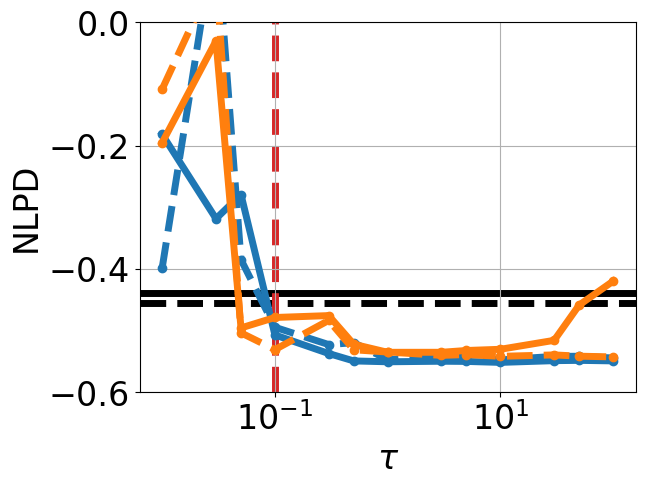

In [11]:
# NLPD
metric = 'nlpd'
title = 'NLPD'

ema_K1 = results[1]['ema'][metric]
ema_K4 = results[4]['ema'][metric]
noema_K1 = results[1]['noema'][metric]
noema_K4 = results[4]['noema'][metric]
baseline_K1 = baselines[1][metric]
baseline_K4 = baselines[4][metric]

fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_ylabel(title, fontsize=24)
ax.set_xlabel(r"$\tau$", fontsize=24)
ax.plot(tau_list, ema_K1, "--o", c='C0', label="VFM (K=1)", linewidth=5, zorder=2)
ax.plot(tau_list, ema_K4, "-o", c='C0', label="VFM (K=4)", linewidth=5, zorder=3)
ax.plot(tau_list, noema_K1, "--o", c='C1', label="VFM (no EMA, K=1)", linewidth=5, zorder=4)
ax.plot(tau_list, noema_K4, "-o", c='C1', label="VFM (no EMA, K=4)", linewidth=5, zorder=5)

xmin, xmax = ax.get_xlim()
ymin, ymax = -0.6, 0.0
ax.hlines(baseline_K1, xmin, xmax, linestyle='--', color='k', label=r"$\mathtt{frozen}$-$\theta$ (K=1)", linewidth=5, zorder=0)
ax.hlines(baseline_K4, xmin, xmax, linestyle="-", color='k', label=r"$\mathtt{frozen}$-$\theta$ (K=4)", linewidth=5, zorder=1)
ax.vlines(sigma, ymin, ymax, linestyle="--", color='C3', linewidth=5, zorder=1)
ax.set_ylim(ymin, ymax)

plt.grid(True)
ax.tick_params(axis='both', which='both', labelsize=24)
# plt.legend(fontsize=18)

plt.savefig(f"figures/metrics/alpha{alpha}/nlpd.pdf", bbox_inches="tight")

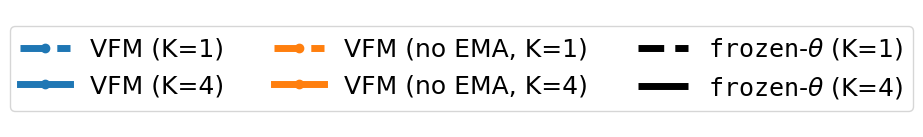

In [9]:
handles, labels = ax.get_legend_handles_labels()  # make sure this is run AFTER plotting everything

fig_leg, ax_leg = plt.subplots(figsize=(10, 1.2))
ax_leg.axis("off")

ax_leg.legend(
    handles, labels,
    ncol=3, loc="center",
    frameon=True, fontsize=18
)

fig_leg.tight_layout(pad=0.1)
plt.savefig(f"figures/metrics/alpha{alpha}/legend.pdf", bbox_inches="tight")


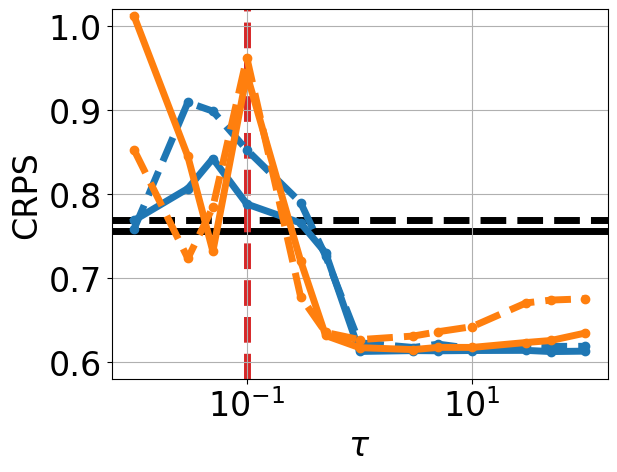

In [142]:
# CRPS
metric = 'crps'
title = 'CRPS'

ema_K1 = results[1]['ema'][metric]
ema_K4 = results[4]['ema'][metric]
noema_K1 = results[1]['noema'][metric]
noema_K4 = results[4]['noema'][metric]
baseline_K1 = baselines[1][metric]
baseline_K4 = baselines[4][metric]

fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_ylabel(title, fontsize=24)
ax.set_xlabel(r"$\tau$", fontsize=24)
ax.plot(tau_list, ema_K1, "--o", c='C0', label="EMA (K=1)", linewidth=5, zorder=2)
ax.plot(tau_list, ema_K4, "-o", c='C0', label="EMA (K=4)", linewidth=5, zorder=3)
ax.plot(tau_list, noema_K1, "--o", c='C1', label="No EMA (K=1)", linewidth=5, zorder=4)
ax.plot(tau_list, noema_K4, "-o", c='C1', label="No EMA (K=4)", linewidth=5, zorder=5)

xmin, xmax = ax.get_xlim()
ymin, ymax = 0.58, 1.02
ax.hlines(baseline_K1, xmin, xmax, linestyle='--', color='k', label="Baseline (K=1)", linewidth=5, zorder=0)
ax.hlines(baseline_K4, xmin, xmax, linestyle="-", color='k', label="Baseline (K=4)", linewidth=5, zorder=1)
ax.vlines(sigma, ymin, ymax, linestyle="--", color='C3', linewidth=5, zorder=1)
ax.set_ylim(ymin, ymax)

plt.grid(True)
ax.tick_params(axis='both', which='both', labelsize=24)
# plt.legend(fontsize=16)
plt.savefig(f"figures/metrics/alpha{alpha}/crps.pdf", bbox_inches="tight")

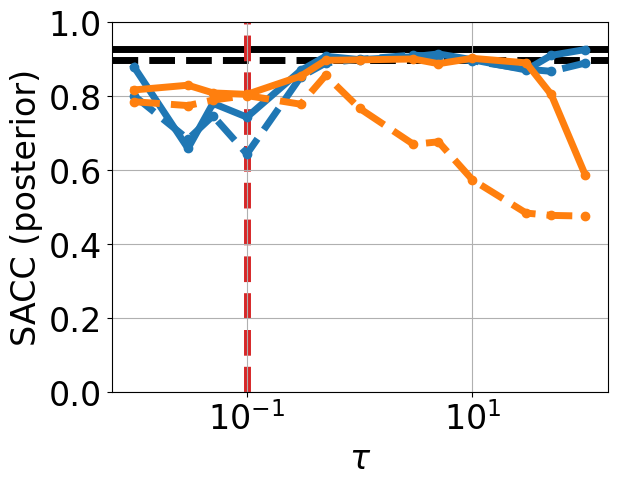

In [130]:
metric = 'sacc_post'
title = 'SACC (posterior)'

ema_K1 = results[1]['ema'][metric]
ema_K4 = results[4]['ema'][metric]
noema_K1 = results[1]['noema'][metric]
noema_K4 = results[4]['noema'][metric]
baseline_K1 = baselines[1][metric]
baseline_K4 = baselines[4][metric]

fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_ylabel(title, fontsize=24)
ax.set_xlabel(r"$\tau$", fontsize=24)
ax.plot(tau_list, ema_K1, "--o", c='C0', label="EMA (K=1)", linewidth=5, zorder=2)
ax.plot(tau_list, ema_K4, "-o", c='C0', label="EMA (K=4)", linewidth=5, zorder=3)
ax.plot(tau_list, noema_K1, "--o", c='C1', label="No EMA (K=1)", linewidth=5, zorder=4)
ax.plot(tau_list, noema_K4, "-o", c='C1', label="No EMA (K=4)", linewidth=5, zorder=5)

xmin, xmax = ax.get_xlim()
ymin, ymax = 0.0, 1.0
ax.hlines(baseline_K1, xmin, xmax, linestyle='--', color='k', label="Baseline (K=1)", linewidth=5, zorder=0)
ax.hlines(baseline_K4, xmin, xmax, linestyle="-", color='k', label="Baseline (K=4)", linewidth=5, zorder=1)
ax.vlines(sigma, ymin, ymax, linestyle="--", color='C3', linewidth=5, zorder=1)
ax.set_ylim(ymin, ymax)

plt.grid(True)
ax.tick_params(axis='both', which='both', labelsize=24)
# plt.legend(fontsize=16)
plt.savefig(f"figures/metrics/alpha{alpha}/sacc_post.pdf", bbox_inches="tight")

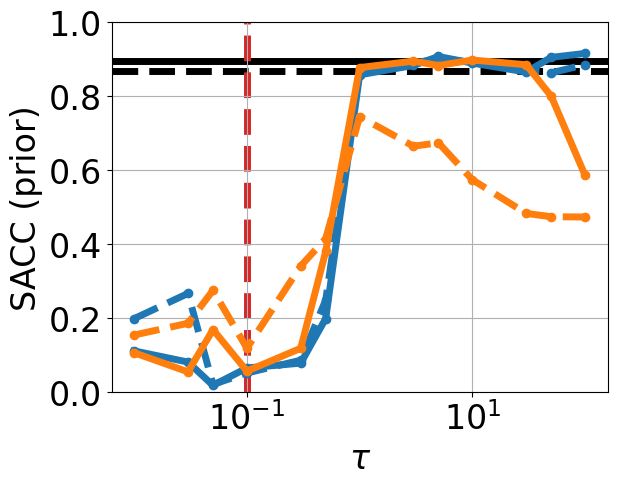

In [131]:
metric = 'sacc_prior'
title = 'SACC (prior)'

ema_K1 = results[1]['ema'][metric]
ema_K4 = results[4]['ema'][metric]
noema_K1 = results[1]['noema'][metric]
noema_K4 = results[4]['noema'][metric]
baseline_K1 = baselines[1][metric]
baseline_K4 = baselines[4][metric]

fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_ylabel(title, fontsize=24)
ax.set_xlabel(r"$\tau$", fontsize=24)
ax.plot(tau_list, ema_K1, "--o", c='C0', label="EMA (K=1)", linewidth=5, zorder=2)
ax.plot(tau_list, ema_K4, "-o", c='C0', label="EMA (K=4)", linewidth=5, zorder=3)
ax.plot(tau_list, noema_K1, "--o", c='C1', label="No EMA (K=1)", linewidth=5, zorder=4)
ax.plot(tau_list, noema_K4, "-o", c='C1', label="No EMA (K=4)", linewidth=5, zorder=5)

xmin, xmax = ax.get_xlim()
ymin, ymax = 0.0, 1.0
ax.hlines(baseline_K1, xmin, xmax, linestyle='--', color='k', label="Baseline (K=1)", linewidth=5, zorder=0)
ax.hlines(baseline_K4, xmin, xmax, linestyle="-", color='k', label="Baseline (K=4)", linewidth=5, zorder=1)
ax.vlines(sigma, ymin, ymax, linestyle="--", color='C3', linewidth=5, zorder=1)
ax.set_ylim(ymin, ymax)

plt.grid(True)
ax.tick_params(axis='both', which='both', labelsize=24)
# plt.legend(fontsize=16)
plt.savefig(f"figures/metrics/alpha{alpha}/sacc_prior.pdf", bbox_inches="tight")

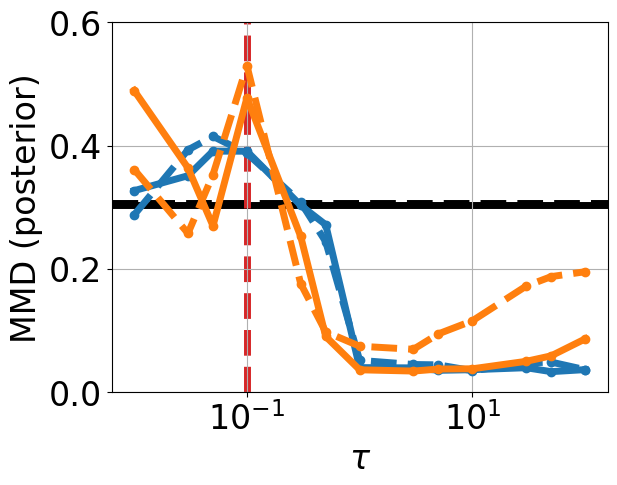

In [132]:
metric = 'mmd_post'
title = 'MMD (posterior)'

ema_K1 = results[1]['ema'][metric]
ema_K4 = results[4]['ema'][metric]
noema_K1 = results[1]['noema'][metric]
noema_K4 = results[4]['noema'][metric]
baseline_K1 = baselines[1][metric]
baseline_K4 = baselines[4][metric]

fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_ylabel(title, fontsize=24)
ax.set_xlabel(r"$\tau$", fontsize=24)
ax.plot(tau_list, ema_K1, "--o", c='C0', label="EMA, K=1", linewidth=5, zorder=2)
ax.plot(tau_list, ema_K4, "-o", c='C0', label="EMA, K=4", linewidth=5, zorder=3)
ax.plot(tau_list, noema_K1, "--o", c='C1', label="No EMA, K=1", linewidth=5, zorder=4)
ax.plot(tau_list, noema_K4, "-o", c='C1', label="No EMA, K=4", linewidth=5, zorder=5)

xmin, xmax = ax.get_xlim()
ymin, ymax = 0.0, 1.0
ax.hlines(baseline_K1, xmin, xmax, linestyle='--', color='k', label="Baseline (K=1)", linewidth=5, zorder=0)
ax.hlines(baseline_K4, xmin, xmax, linestyle="-", color='k', label="Baseline (K=4)", linewidth=5, zorder=1)
ax.vlines(sigma, ymin, ymax, linestyle="--", color='C3', linewidth=5, zorder=1)
ax.set_ylim(ymin, ymax)

plt.grid(True)
ax.tick_params(axis='both', which='both', labelsize=24)
ax.set_ylim(0.0, 0.6)
# plt.legend(fontsize=16)
plt.savefig(f"figures/metrics/alpha{alpha}/mmd_post.pdf", bbox_inches="tight")

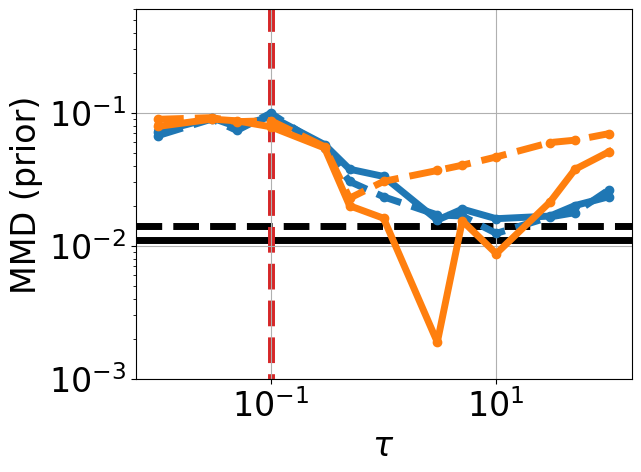

In [7]:
metric = 'mmd_prior'
title = 'MMD (prior)'

ema_K1 = results[1]['ema'][metric]
ema_K4 = results[4]['ema'][metric]
noema_K1 = results[1]['noema'][metric]
noema_K4 = results[4]['noema'][metric]
baseline_K1 = baselines[1][metric]
baseline_K4 = baselines[4][metric]

fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(title, fontsize=24)
ax.set_xlabel(r"$\tau$", fontsize=24)
ax.plot(tau_list, ema_K1, "--o", c='C0', label="EMA (K=1)", linewidth=5, zorder=2)
ax.plot(tau_list, ema_K4, "-o", c='C0', label="EMA (K=4)", linewidth=5, zorder=3)
ax.plot(tau_list, noema_K1, "--o", c='C1', label="No EMA (K=1)", linewidth=5, zorder=4)
ax.plot(tau_list, noema_K4, "-o", c='C1', label="No EMA (K=4)", linewidth=5, zorder=5)

xmin, xmax = ax.get_xlim()
ymin, ymax = 0.0, 1.0
ax.hlines(baseline_K1, xmin, xmax, linestyle='--', color='k', label="Baseline (K=1)", linewidth=5, zorder=0)
ax.hlines(baseline_K4, xmin, xmax, linestyle="-", color='k', label="Baseline (K=4)", linewidth=5, zorder=1)
ax.vlines(sigma, ymin, ymax, linestyle="--", color='C3', linewidth=5, zorder=1)
# ax.set_ylim(ymin, ymax)

plt.grid(True)
ax.tick_params(axis='both', which='both', labelsize=24)
ax.set_ylim(1e-3, 0.6)
# plt.legend(fontsize=16)
plt.savefig(f"figures/metrics/alpha{alpha}/mmd_prior.pdf", bbox_inches="tight")